In [11]:
import rioxarray as rxr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import subprocess
import os
import pandas as pd
import xarray as xr
import rasterio as rio
from scipy.interpolate import griddata
from rasterio.enums import Resampling
from pyproj import Transformer
from xrspatial import hillshade
import sys
import glob
sys.path.insert(0,"/home/jovyan/shared/Libraries")
import victor

### Inputs

In the following cell, we ask for a few basic inputs from you, and use standardized values for physical & rheological properties in each of our models. If you would like to further edit the models, refer further down to additional guidance unique to each simulation.

In [2]:
easting = 329204

northing = 377842

dem = "/home/jovyan/shared/DEMs/Iceland_20mx20m_cropped.tif"

volume = 1e8

name = "fagradasfjall"

# For IMEX, we assign a reasonable yet arbitrary time for the flow to run (in seconds)
# Please change it at your leisure
run_time = 1000

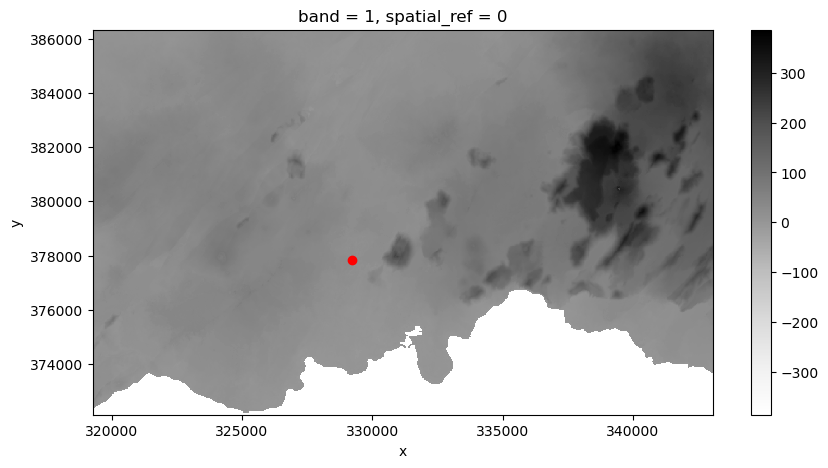

In [3]:
coordinates = np.array([easting, northing])
raster = rxr.open_rasterio(dem, masked=True).squeeze()
f, ax = plt.subplots(figsize=(10, 5))
raster.plot(cmap="Greys",
                 ax=ax)
plt.scatter(easting, northing,c='red')

In [4]:
raster = rxr.open_rasterio(dem)
raster = raster.sel({"band": 1})
xll, yll = int(raster.x.min()), int(raster.y.min())
coordinates = np.array([int(easting),int(northing)])
r = rio.open(dem)
res = r.res

output_num = str(int(run_time/100))
out = output_num.zfill(4)

filename, file_extension = os.path.splitext(dem)
file_name = os.path.basename(dem)
file_name = os.path.splitext(file_name)[0]
type_flag = 0 #0 is ascii, 1 is tiff
if file_extension in [".geotiff", ".tiff", ".tif"]:
    type_flag = 1
    asc_name = "".join((file_name, ".asc"))
    raster.rio.to_raster(asc_name)
    os.remove("".join((asc_name, ".aux.xml")))
    os.remove("".join((file_name, ".prj")))
    cell_size = open(f"""{asc_name}""","r+")
    info = cell_size.readlines()
    uniform = info[4].split()
    if uniform[0] == 'dx':
        info[4] = f"""cellsize     {int(float(uniform[1]))}\n"""
        info[5] = ""
        cell_size.seek(0)
        cell_size.writelines(info)
        cell_size.truncate()
        cell_size.close()
elif file_extension in [".asc", ".ascii"]:
    type_flag = 0
    tiff_name = "".join((file_name, ".tiff"))
    raster.rio.to_raster(tiff_name)

### Molasses: Additional Notes

Molasses input parameters are stored in `custom_molasses.conf` in the `Molasses` folder. The most impactful change would be that of changing the minimum and maximum residual, as the cellular automata structure will cause a much larger or smaller area to be impacted. As a stochastic model, no physical parameters are used.

In [5]:
os.chdir("/home/jovyan/Lava Benchmark/Molasses")
f = open("custom_molasses.conf","r+")
conf = f.readlines()
conf[4] = f"""MIN_TOTAL_VOLUME = {str(volume)}\n"""
conf[5] = f"""MAX_TOTAL_VOLUME = {str(volume)}\n"""
conf[6] = f"""MIN_PULSE_VOLUME = {float(volume)/100}\n"""
conf[7] = f"""MAX_PULSE_VOLUME = {float(volume)/100}\n"""
conf[10] = f"""DEM_FILE = {dem}\n"""
f.seek(0)
f.writelines(conf)
f.truncate()
f.close()

f=open("events.in","w")
f.write(f"""{easting},{northing}""")
f.close()

if not os.path.exists(f"{dem}"):
    subprocess.run(f"""ln -s {dem} .""",shell=True)
subprocess.run("molasses custom_molasses.conf",shell=True, stderr=subprocess.DEVNULL)

victor.convert_molasses(f"molasses")
os.chdir("/home/jovyan/Lava Benchmark")

Seeding random number generator: 1749570172


               MOLASSES is a lava flow simulator.

Config file: custom_molasses.conf
Reading in Parameters...
             PARENTS = 1                    [assigned]
    ELEVATION_UNCERT = 0                    [assigned]
        MIN_RESIDUAL = .1                   [assigned]
        MAX_RESIDUAL = 2                    [assigned]
    MIN_TOTAL_VOLUME = 100000000.0          [assigned]
    MAX_TOTAL_VOLUME = 100000000.0          [assigned]
    MIN_PULSE_VOLUME = 1000000.0            [assigned]
    MAX_PULSE_VOLUME = 1000000.0            [assigned]
                RUNS = 1                    [assigned]
      ASCII_FLOW_MAP = 1                    [assigned]
            DEM_FILE = /home/jovyan/shared/DEMs/Iceland_20mx20m_cropped.tif [assigned]
[assigned]VENTS_FILE = events.in            
Nothing missing.

DEM Information [GeoTIFF]:
  File:              /home/jovyan/shared/DEMs/Iceland_20mx20m_cropped.tif
  Lower Left Origin: (319260.096700,372119.

### MrLavaLoba: Additional Notes

MrLavaLoba input parameters are stored in `input_data.py` in the `mr_lava_loba` folder. The most impactful changes would be those such as the thickening parameter, lobe exponent, or max slope probability. Other parameters not mentioned will also affect the creation and placement of lobes. As a stochastic model, no physical parameters are specified by the user.

In [6]:
os.chdir("/home/jovyan/Lava Benchmark/mr_lava_loba")
g=open("input_data.py","r+")
inp = g.readlines()
inp[1] = f"""run_name = '{name}'\n"""
if type_flag == 1:
    inp[3] = f"""source = '{asc_name}'\n"""
else:
    inp[3] = f"""source = '{dem}'\n"""
inp[42] = f"""vent_flag = 0\n"""
inp[45] = f"""x_vent = [{int(easting)}]\n"""
inp[46] = f"""y_vent = [{int(northing)}]\n"""
inp[92] = f"""total_volume = {volume}\n"""
inp[97] = f"""fixed_dimension_flag = 1\n"""
g.seek(0)
g.writelines(inp)
g.truncate()
g.close()

if type_flag == 1:
    subprocess.run(f"""ln -s ../{asc_name} .""",shell=True)
else:
    subprocess.run(f"""ln -s ../{dem} .""",shell=True)
subprocess.run("python mr_lava_loba.py",shell=True)
if type_flag == 1:
    os.remove(asc_name)
else:
    os.remove(dem)
os.chdir("/home/jovyan/Lava Benchmark/")

ln: failed to create symbolic link './Iceland_20mx20m_cropped.asc': File exists



Mr Lava Loba by M.de' Michieli Vitturi and S.Tarquini

x_vent_end not used
y_vent_end not used
fissure_probabilities not used
Run name fagradasfjall_000

Maximum number of lobes 1200
Average Lobe thickness = 0.085034 m

west_to_vent 10000.0
x_vent [329204]
Crop flag =  True
Iceland_20mx20m_cropped.npy  exists
Cropping of original DEM
xW,xE,yS,yN 319204.0 339204.0 367842.0 387842.0
iW,iE,jS,jN 0 998 0 711

Time to read DEM 0.3612935260000001s
Channel parameters not defined:
- channel_file
- d1
- d2
- eps
- alfa_chaneel

Restart_files not used
max_semiaxis 33.37790589062273
max_cells 6
End pre-processing

[====================] 100% 0:00:01

Total number of lobes 840000 Average number of lobes 1200

Time elapsed 362.009414872 sec. / 6 min.

Saving files

fagradasfjall_000_thickness_full.asc saved
Union_diff_file not defined

Masking threshold 0.96
Total volume 99994167.49811035  m3 Masked volume 95991349.35752076  m3 Volume fraction 0.959969483813491
Total area 6647200.0  m2 Masked area

### IMEX_Lava: Additional Notes

IMEX_Lava input parameters are stored in `IMEX_LavaFlow.inp` in the `IMEX` folder. This is a physics-based, highly accurate, slower model. If desiring to change additional input parameters, we recommend editing the `TEMPERATURE_PARAMETERS`, `RHEOLOGY_PARAMETERS`, `GAS_TRANSPORT_PARAMETERS`, and `LIQUID_TRANSPPORT_PARAMETERS` namelists as needed. All other sections are carefully prepared based in your initial basic inputs, so ignore all other sections.

In [ ]:
array = rxr.open_rasterio(dem)
os.chdir("/home/jovyan/Lava Benchmark/IMEX_LavaFlow")
h=open("IMEX_LavaFlow.inp","r+")
inp = h.readlines()
inp[1] = f''' RUN_NAME="{name}"\n'''
inp[4] = f""" T_END=  {run_time},\n"""
inp[5] = f""" DT_OUTPUT=  100,\n"""
inp[13] = f""" X0= {int(xll)+1}     ,\n"""
inp[14] = f""" Y0= {int(yll)+1}     ,\n"""
inp[15] = f""" COMP_CELLS_X=  {len(array.x)-5},\n"""
inp[16] = f""" COMP_CELLS_Y=  {len(array.y)-5},\n"""
inp[17] = f""" CELL_SIZE = {res[0]}D0 ,\n"""
inp[103] = f"""  X_SOURCE=  {int(easting)}.0D0 ,\n"""
inp[104] = f"""  Y_SOURCE=  {int(northing)}.0D0 ,\n"""
inp[105] = f"""  R_SOURCE=  {res[0]}D0     ,\n"""
inp[106] = f""" VEL_SOURCE= {float(volume)/(res[0]**2*np.pi*run_time)} \n"""
h.seek(0)
h.writelines(inp)
h.truncate()
h.close()

if type_flag == 1:
    subprocess.run(f"""ln -s ../{asc_name} topography_dem.asc""",shell=True)
else:
    subprocess.run(f"""ln -s {dem} topography_dem.asc""",shell=True)
subprocess.run("./IMEX_LavaFlow",shell=True)
os.remove("topography_dem.asc")
os.chdir("/home/jovyan/Lava Benchmark")

### LAVA2D: Additional Notes

LAVA2D input parameters are stored in `input.py` in the `lava2d` folder. This is a physics-based, highly accurate, slower model. If desiring to change additional input parameters, we recommend editing the `set_vent_props`, `set_lava_props`, `set_rheo`, `set_ambient`, and `set_numeric` sections as needed. All other sections are carefully prepared based in your initial basic inputs, so please leave them as is.

In [8]:
os.chdir("/home/jovyan/Lava Benchmark/lava2d")
transformer = Transformer.from_crs("EPSG:3057", "EPSG:4326")
rast = rio.open(dem)
left, bottom, right, top = rast.bounds
lower_left = transformer.transform(left, bottom)
top_right = transformer.transform(right, top)
src = transformer.transform(easting, northing)

l = open("input.py","r+")
inp = l.readlines()

if type_flag == 0:
    inp[4] = f"""    path_to_dem_file    = ('{tiff_name}'),\n"""
else:
    inp[4] = f"""    path_to_dem_file    = ('{dem}'),\n"""
inp[5] = f"""    Lon_SRC             = {src[1]}, # source longitude\n"""
inp[6] = f"""    Lat_SRC             = {src[0]},    # source latitude\n"""
inp[7] = f"""    Lon_LowerLeft       = {lower_left[1]}, # bounding box: lower-left longitude\n"""
inp[8] = f"""    Lat_LowerLeft       = {lower_left[0]}, # bounding box: lower-left latitude\n"""
inp[9] = f"""    Lon_UpperRight      = {top_right[1]}, # bounding box: upper-right longitude\n"""
inp[10] = f"""    Lat_UpperRight      = {top_right[0]},   # bounding box: upper-right latitude\n"""
inp[67] = f"""    max_iter = None, #one of them can be none, so the default value for both is none, if both none run till killed\n"""

inp[68] = f"""    max_time_hr = {run_time/3600},\n"""
l.seek(0)
l.writelines(inp)
l.truncate()
l.close()

k=open("./example_vents/vent_01.txt","r+")
inp = k.readlines()
inp[1] = f'''0	0	0	100	-75	20	{volume/(run_time*50)}\n'''
inp[2] = f'''10000	0	0	100	-75	20	{volume/(run_time*50)}\n'''

k.seek(0)
k.writelines(inp)
k.truncate()
k.close()

subprocess.run("python input.py",shell=True)

| --- Reading DEM Dataset --- |
| --- Building Modelling Subset --- |
| --- Building Coordinate Transform --- |
| --- Preparing DEM --- |
| --- DEM Preparation Complete --- |
| --- Initializing Model Domain --- |
| --- Beginning Model Evolution --- |
|  Step (sub): 10 (1)  |  dx: 80.00002453781512 m  |  Grid: 33 x 33  |  dt (type): 5.000 s (max)  |  t: 0.01 hr |
|  Step (sub): 20 (1)  |  dx: 80.00002453781512 m  |  Grid: 33 x 33  |  dt (type): 4.029 s (hyp)  |  t: 0.02 hr |
|  Step (sub): 30 (1)  |  dx: 80.00002453781512 m  |  Grid: 33 x 33  |  dt (type): 2.833 s (par)  |  t: 0.03 hr |
|  Step (sub): 40 (1)  |  dx: 80.00002453781512 m  |  Grid: 33 x 33  |  dt (type): 2.090 s (par)  |  t: 0.04 hr |
|  Step (sub): 50 (1)  |  dx: 80.00002453781512 m  |  Grid: 33 x 33  |  dt (type): 1.731 s (par)  |  t: 0.05 hr |
|  Step (sub): 60 (1)  |  dx: 80.00002453781512 m  |  Grid: 33 x 33  |  dt (type): 1.537 s (par)  |  t: 0.05 hr |
|  Step (sub): 70 (1)  |  dx: 80.00002453781512 m  |  Grid: 33 x 

CompletedProcess(args='python input.py', returncode=0)

/srv/conda/envs/notebook/lib/python3.10/site-packages/xrspatial/hillshade.py:19: RuntimeWarning: overflow encountered in multiply
  slope = np.pi/2. - np.arctan(np.sqrt(x*x + y*y))
/srv/conda/envs/notebook/lib/python3.10/site-packages/xrspatial/hillshade.py:19: RuntimeWarning: overflow encountered in multiply
  slope = np.pi/2. - np.arctan(np.sqrt(x*x + y*y))
/srv/conda/envs/notebook/lib/python3.10/site-packages/xrspatial/hillshade.py:19: RuntimeWarning: overflow encountered in multiply
  slope = np.pi/2. - np.arctan(np.sqrt(x*x + y*y))


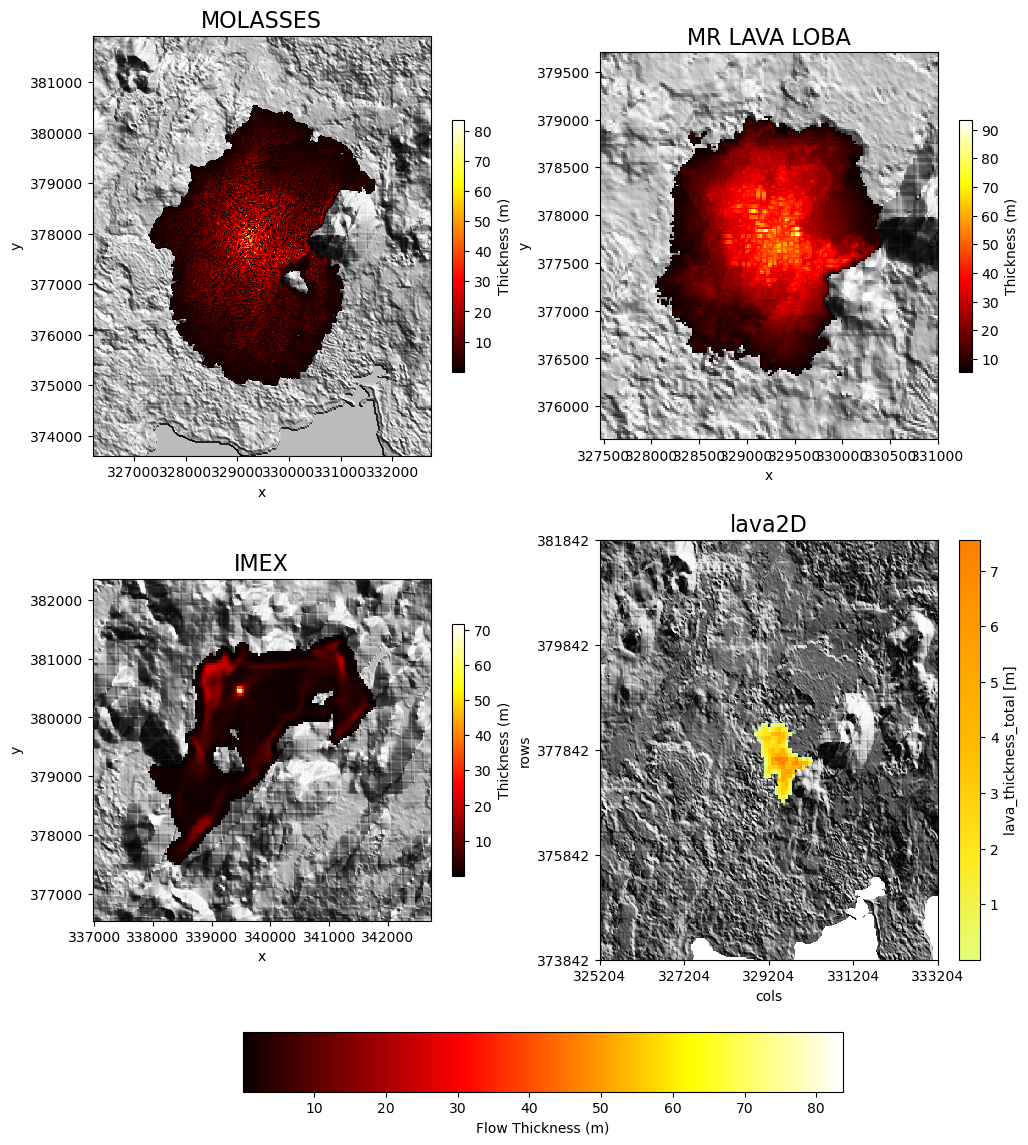

In [19]:
os.chdir("/home/jovyan/Lava Benchmark/")
mll_outputs = sorted(glob.glob(f'mr_lava_loba/{name}*thickness_masked*.asc'))
mll_out = mll_outputs[-1]

fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(ncols=2, nrows=2, figsize = (12,12))

ax0.cla()
east, north = easting, northing

thickness0 = victor.plot_flow(dem, "./Molasses/molasses.asc", axes=ax0)
ax0.set_title('MOLASSES', fontsize=16)

ax1.cla()
thickness1 =victor.plot_flow(dem, mll_out, axes=ax1)
ax1.set_title('MR LAVA LOBA', fontsize=16)
ax1.set_aspect("equal")

ax2.cla()
thickness2 = victor.plot_flow(dem, f"""./IMEX_LavaFlow/fagradalsfjall_0002.asc""", axes=ax2)
ax2.set_title('IMEX', fontsize=16)
ax2.set_aspect("equal")

ax3.cla()
raster = rxr.open_rasterio(dem, masked=True).squeeze()
ds = xr.open_dataset("lava2d/outputs/out.nc",group="DATA/PHYSICS")
ds = ds.where(ds != 0)
lava = ds['lava_thickness_total']
da = xr.open_dataset("lava2d/outputs/out.nc",group="DATA")
es = da.x.values[0] + easting
ns = da.y.values[:,0] + northing
lava = lava.assign_coords(rows=ns)
lava = lava.assign_coords(cols=es)
ax3.set_xticks(np.linspace(east-4000, east+4000,5))
ax3.set_yticks(np.linspace(north-4000, north+4000,5))
ax3.set_xlim([east-4000, east+4000])
ax3.set_ylim([north-4000, north+4000])
raster_agg = hillshade(raster)
render = raster_agg.plot.imshow(ax=ax3,cmap="Greys")
render.colorbar.remove()
lava.plot.imshow(ax=ax3,cmap="Wistia")
ax3.set_title('lava2D', fontsize=16)

cbar_ax = fig.add_axes([.25, 0, 0.5, 0.05])
fig.colorbar(thickness0, cax=cbar_ax, label="Flow Thickness (m)", orientation="horizontal")